In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)

# CSV'yi Parquet formatına dönüştür (ilk kez çalıştırıldığında)
CSV_PATH = Path("../DATA/hotel_data__20260818.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("DATA/hotel_data__20260818.csv")

PARQUET_PATH = CSV_PATH.parent / "hotel_data__20260818.parquet"

if not PARQUET_PATH.exists():
    print(f"CSV okunuyor: {CSV_PATH.resolve()}")
    df_temp = pd.read_csv(CSV_PATH, sep=";", decimal=",", low_memory=False)
    print(f"Yüklendi: {df_temp.shape[0]:,} satır x {df_temp.shape[1]} sütun")
    print(f"Parquet formatına dönüştürülüyor...")
    df_temp.to_parquet(PARQUET_PATH, compression='snappy')
    csv_size = CSV_PATH.stat().st_size / (1024*1024)
    parquet_size = PARQUET_PATH.stat().st_size / (1024*1024)
    print(f"✓ CSV: {csv_size:.2f} MB → Parquet: {parquet_size:.2f} MB ({(1-parquet_size/csv_size)*100:.1f}% sıkıştırma)")
    del df_temp
else:
    print(f"✓ Parquet dosyası mevcut: {PARQUET_PATH.resolve()}")

DATA_PATH = PARQUET_PATH
print(f"Hazır. Veri dosyası: {DATA_PATH.resolve()}")

CSV okunuyor: C:\Users\efe.turhan\Desktop\sales_forecasting\data\hotel_data__20260818.csv
Yüklendi: 473,569 satır x 40 sütun
Parquet formatına dönüştürülüyor...
✓ CSV: 104.71 MB → Parquet: 17.01 MB (83.8% sıkıştırma)
Hazır. Veri dosyası: C:\Users\efe.turhan\Desktop\sales_forecasting\data\hotel_data__20260818.parquet


## 1. Veriyi Oku ve Hazırla

Bu hücreyi çalıştırdıktan sonra `df.info()` ve örnek kayıtları kontrol et.

In [4]:
# Parquet dosyasını oku
pd.set_option("display.max_columns", None)
df = pd.read_parquet(DATA_PATH)
print(f"Yüklendi: {df.shape[0]:,} satır x {df.shape[1]} sütun")

DROP_COLS = [
    "termal_otel", "alkolsuz_otel", "yetiskin_otel", "balayi_otel",
    "cevre_dostu_otel", "kayak_otel", "evcil_hayvan_kabul_eden_otel",
    "cocuk_dostu_otel", "denize_sifir_otel", "room_count",
    "accomodation_start_date", "accomodation_end_date"
]
df = df.drop(columns=[col for col in DROP_COLS if col in df.columns])
print(f"Analiz için tutulan sütun sayısı: {df.shape[1]}")

DATE_COLS = [
    "checkin_date", "checkout_date", "voucher_created_date"
]
NUMERIC_COLS = [
    "checkin_yil", "checkin_ay", "checkin_gun", "checkout_yil", "checkout_ay",
    "checkout_gun", "accommodation_period", "sehir_id", "otel_bolge_id", "otel_id",
    "otel_kategori_id", "hotel_board_type_id", "is_setur_hotel",
    "hotel_voucher_guest_count", "buying_price", "listing_price",
    "selling_price", "campaign"
]

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce", format="mixed")
for col in NUMERIC_COLS:
    if col in df.columns:
        if df[col].dtype == "object":
            df[col] = (df[col].astype(str).str.replace(".", "", regex=False)
                       .str.replace(",", ".", regex=False))
        df[col] = pd.to_numeric(df[col], errors="coerce")

raw_shape = df.shape
display(df.head(10))

Yüklendi: 473,569 satır x 40 sütun
Analiz için tutulan sütun sayısı: 28


,hotel_voucher_id,checkin_date,checkin_yil,checkin_ay,checkin_gun,checkout_date,checkout_yil,checkout_ay,checkout_gun,accommodation_period,sehir_id,sehir_adi,otel_bolge_id,otel_bolge_adi,otel_id,otel_adi,otel_kategori_id,otel_kategori_adi,hotel_board_type_id,hotel_board_type_name,is_setur_hotel,hotel_voucher_guest_count,voucher_created_date,buying_price,listing_price,selling_price,campaign,currency_code
0,519854,2027-08-11,2027,8,11,2027-08-12,2027,8,12,1,80,Muğla,7866.0,Muğla Dalyan,1659,Han Dalyan Hotel,19,Otel,10.0,Oda Kahvaltı,1,4,2026-08-11 15:35:00,80.76,95.00,95.00,0,EUR
1,510485,2027-07-31,2027,7,31,2027-08-01,2027,8,1,1,29,Antalya,7467.0,Muratpaşa,168467,Ring Downtown Hotel,4,4 Yıldız,10.0,Oda Kahvaltı,1,2,2026-07-27 11:24:00,6527.32,7679.20,7679.20,0,TRY
2,523176,2027-07-20,2027,7,20,2027-08-05,2027,8,5,16,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-17 13:24:00,243507.20,380480.00,295252.48,1,TRY
3,515167,2027-07-20,2027,7,20,2027-07-24,2027,7,24,4,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-04 06:46:00,60876.80,95120.00,76096.00,1,TRY
4,522583,2027-07-04,2027,7,4,2027-07-11,2027,7,11,7,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-16 12:09:00,106534.40,166460.00,133168.00,1,TRY
5,523149,2027-06-26,2027,6,26,2027-06-28,2027,6,28,2,80,Muğla,8273.0,Sarıgerme,458,Robinson Sarıgerme Park,4,4 Yıldız,246.0,Robinson Her Şey Dahil,1,3,2026-08-17 12:50:00,39569.92,61828.00,49462.40,1,TRY
6,521314,2027-05-21,2027,5,21,2027-05-22,2027,5,22,1,1489,Bükreş,NaN,NaN,276525,Hotel Funnytime,3,3 Yıldız,NaN,Sadece Oda,0,3,2026-08-14 07:01:00,60.82,68.04,60.82,1,EUR
7,522688,2027-05-20,2027,5,20,2027-05-25,2027,5,25,5,29,Antalya,7930.0,Kumköy,647,Crystal Sunset Pearl Collection,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,2,2026-08-16 14:51:00,51620.60,96600.00,62790.00,1,TRY
8,481413,2027-05-20,2027,5,20,2027-05-22,2027,5,22,2,2189,Bangkok,NaN,NaN,170019,Holiday Inn Express Bangkok Siam by IHG,4,4 Yıldız,NaN,Ücretsiz Kahvaltı,0,2,2026-06-06 17:55:00,166.77,166.77,166.77,0,EUR
9,521309,2027-05-19,2027,5,19,2027-05-21,2027,5,21,2,1493,Cluj-Napoca,NaN,NaN,2012578,Palazzo Bellariva Dimora,3,3 Yıldız,NaN,Ücretsiz Kahvaltı,0,3,2026-08-14 06:44:00,156.32,223.32,156.32,1,EUR


## 2. Veri Genel İncelemesi ve Eksikler

Boyut: 473,569 satır x 28 sütun


,kolon,tip,benzersiz,eksik,eksik_oran_%
0,hotel_voucher_id,int64,473569,0,0.000
1,checkin_date,datetime64[us],2218,0,0.000
2,checkin_yil,int64,7,0,0.000
3,checkin_ay,int64,12,0,0.000
4,checkin_gun,int64,31,0,0.000
5,checkout_date,datetime64[us],2222,0,0.000
6,checkout_yil,int64,7,0,0.000
7,checkout_ay,int64,12,0,0.000
8,checkout_gun,int64,31,0,0.000
9,accommodation_period,int64,57,0,0.000


,hotel_voucher_id,checkin_date,checkin_yil,checkin_ay,checkin_gun,checkout_date,checkout_yil,checkout_ay,checkout_gun,accommodation_period,sehir_id,sehir_adi,otel_bolge_id,otel_bolge_adi,otel_id,otel_adi,otel_kategori_id,otel_kategori_adi,hotel_board_type_id,hotel_board_type_name,is_setur_hotel,hotel_voucher_guest_count,voucher_created_date,buying_price,listing_price,selling_price,campaign,currency_code
0,519854,2027-08-11,2027,8,11,2027-08-12,2027,8,12,1,80,Muğla,7866.0,Muğla Dalyan,1659,Han Dalyan Hotel,19,Otel,10.0,Oda Kahvaltı,1,4,2026-08-11 15:35:00,80.76,95.00,95.00,0,EUR
1,510485,2027-07-31,2027,7,31,2027-08-01,2027,8,1,1,29,Antalya,7467.0,Muratpaşa,168467,Ring Downtown Hotel,4,4 Yıldız,10.0,Oda Kahvaltı,1,2,2026-07-27 11:24:00,6527.32,7679.20,7679.20,0,TRY
2,523176,2027-07-20,2027,7,20,2027-08-05,2027,8,5,16,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-17 13:24:00,243507.20,380480.00,295252.48,1,TRY
3,515167,2027-07-20,2027,7,20,2027-07-24,2027,7,24,4,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-04 06:46:00,60876.80,95120.00,76096.00,1,TRY
4,522583,2027-07-04,2027,7,4,2027-07-11,2027,7,11,7,29,Antalya,7827.0,Çamyuva,456,Robinson Çamyuva,7,Tatil Köyü,246.0,Robinson Her Şey Dahil,1,2,2026-08-16 12:09:00,106534.40,166460.00,133168.00,1,TRY
5,523149,2027-06-26,2027,6,26,2027-06-28,2027,6,28,2,80,Muğla,8273.0,Sarıgerme,458,Robinson Sarıgerme Park,4,4 Yıldız,246.0,Robinson Her Şey Dahil,1,3,2026-08-17 12:50:00,39569.92,61828.00,49462.40,1,TRY
6,521314,2027-05-21,2027,5,21,2027-05-22,2027,5,22,1,1489,Bükreş,NaN,NaN,276525,Hotel Funnytime,3,3 Yıldız,NaN,Sadece Oda,0,3,2026-08-14 07:01:00,60.82,68.04,60.82,1,EUR
7,522688,2027-05-20,2027,5,20,2027-05-25,2027,5,25,5,29,Antalya,7930.0,Kumköy,647,Crystal Sunset Pearl Collection,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,2,2026-08-16 14:51:00,51620.60,96600.00,62790.00,1,TRY
8,481413,2027-05-20,2027,5,20,2027-05-22,2027,5,22,2,2189,Bangkok,NaN,NaN,170019,Holiday Inn Express Bangkok Siam by IHG,4,4 Yıldız,NaN,Ücretsiz Kahvaltı,0,2,2026-06-06 17:55:00,166.77,166.77,166.77,0,EUR
9,521309,2027-05-19,2027,5,19,2027-05-21,2027,5,21,2,1493,Cluj-Napoca,NaN,NaN,2012578,Palazzo Bellariva Dimora,3,3 Yıldız,NaN,Ücretsiz Kahvaltı,0,3,2026-08-14 06:44:00,156.32,223.32,156.32,1,EUR


,hotel_voucher_id,checkin_date,checkin_yil,checkin_ay,checkin_gun,checkout_date,checkout_yil,checkout_ay,checkout_gun,accommodation_period,sehir_id,sehir_adi,otel_bolge_id,otel_bolge_adi,otel_id,otel_adi,otel_kategori_id,otel_kategori_adi,hotel_board_type_id,hotel_board_type_name,is_setur_hotel,hotel_voucher_guest_count,voucher_created_date,buying_price,listing_price,selling_price,campaign,currency_code
473559,45626,2021-01-02,2021,1,2,2021-01-04,2021,1,4,2,40,Bolu,7499.0,Abant,443,Büyük Abant Oteli & Kongre Merkezi,5,5 Yıldız,9.0,Yarım Pansiyon,1,3,2020-12-15 13:50:00,2550.00,3400.0,2890.0,1,TRY
473560,45598,2021-01-02,2021,1,2,2021-01-04,2021,1,4,2,24,Afyonkarahisar,7441.0,Sandıklı,1018,May Thermal Resort & SPA,5,5 Yıldız,5.0,Tam Pansiyon,0,2,2020-12-14 13:09:00,1080.00,1440.0,1296.0,1,TRY
473561,45803,2021-01-02,2021,1,2,2021-01-03,2021,1,3,1,87,Sakarya,7699.0,Sapanca,167802,Del Lago Luxury Hotel By Saraçoglu Sapanca,3,3 Yıldız,10.0,Oda Kahvaltı,1,2,2020-12-23 06:22:00,42.50,50.0,50.0,0,EUR
473562,45828,2021-01-01,2021,1,1,2021-01-03,2021,1,3,2,87,Sakarya,7699.0,Sapanca,167775,NG Enjoy,5,5 Yıldız,9.0,Yarım Pansiyon,1,2,2020-12-23 13:01:00,2880.00,3600.0,3312.0,1,TRY
473563,45829,2021-01-01,2021,1,1,2021-01-03,2021,1,3,2,87,Sakarya,7699.0,Sapanca,167775,NG Enjoy,5,5 Yıldız,9.0,Yarım Pansiyon,1,2,2020-12-23 13:01:00,2880.00,3600.0,3312.0,1,TRY
473564,45381,2021-01-01,2021,1,1,2021-01-03,2021,1,3,2,87,Sakarya,7699.0,Sapanca,2874,Sapanca Alfa Suites & Spa,19,Otel,10.0,Oda Kahvaltı,1,2,2020-11-29 12:55:00,1245.25,1600.0,1430.0,1,TRY
473565,46040,2021-01-01,2021,1,1,2021-01-02,2021,1,2,1,28,Ankara,8262.0,Çukurambar,2168,Ataköşk Group Hotels,5,5 Yıldız,10.0,Oda Kahvaltı,1,2,2021-01-01 06:57:00,270.00,540.0,351.0,1,TRY
473566,45862,2021-01-01,2021,1,1,2021-01-04,2021,1,4,3,29,Antalya,7934.0,İleribaşı Mevkii,436,Limak Atlantis De Luxe Hotel & Resort,5,5 Yıldız,3.0,Her Şey Dahil,1,3,2020-12-24 15:01:00,2100.00,3000.0,2280.0,1,TRY
473567,45157,2021-01-01,2021,1,1,2021-01-03,2021,1,3,2,40,Bolu,7499.0,Abant,867,Abant Aden Boutique Hotel,8,Butik Otel,10.0,Oda Kahvaltı,1,2,2020-11-17 07:15:00,1600.00,2000.0,1800.0,1,TRY
473568,45495,2021-01-01,2021,1,1,2021-01-04,2021,1,4,3,5085,Girne,7951.0,Girne Merkez,1294,Lords Palace Hotel Spa Casino,5,5 Yıldız,6.0,Tam Pansiyon Plus,1,2,2020-12-08 16:34:00,2270.00,4540.0,2451.6,1,TRY


Index(['hotel_voucher_id', 'checkin_date', 'checkin_yil', 'checkin_ay',
       'checkin_gun', 'checkout_date', 'checkout_yil', 'checkout_ay',
       'checkout_gun', 'accommodation_period', 'sehir_id', 'sehir_adi',
       'otel_bolge_id', 'otel_bolge_adi', 'otel_id', 'otel_adi',
       'otel_kategori_id', 'otel_kategori_adi', 'hotel_board_type_id',
       'hotel_board_type_name', 'is_setur_hotel', 'hotel_voucher_guest_count',
       'voucher_created_date', 'buying_price', 'listing_price',
       'selling_price', 'campaign', 'currency_code'],
      dtype='str')

### Eksik Veri Özeti

,kolon,tip,benzersiz,eksik,eksik_oran_%
18,hotel_board_type_id,float64,113,58616,12.377
12,otel_bolge_id,float64,655,36564,7.721
13,otel_bolge_adi,str,644,36564,7.721
19,hotel_board_type_name,str,173,14562,3.075
4,checkin_gun,int64,31,0,0.000
5,checkout_date,datetime64[us],2222,0,0.000
6,checkout_yil,int64,7,0,0.000
7,checkout_ay,int64,12,0,0.000
0,hotel_voucher_id,int64,473569,0,0.000
1,checkin_date,datetime64[us],2218,0,0.000


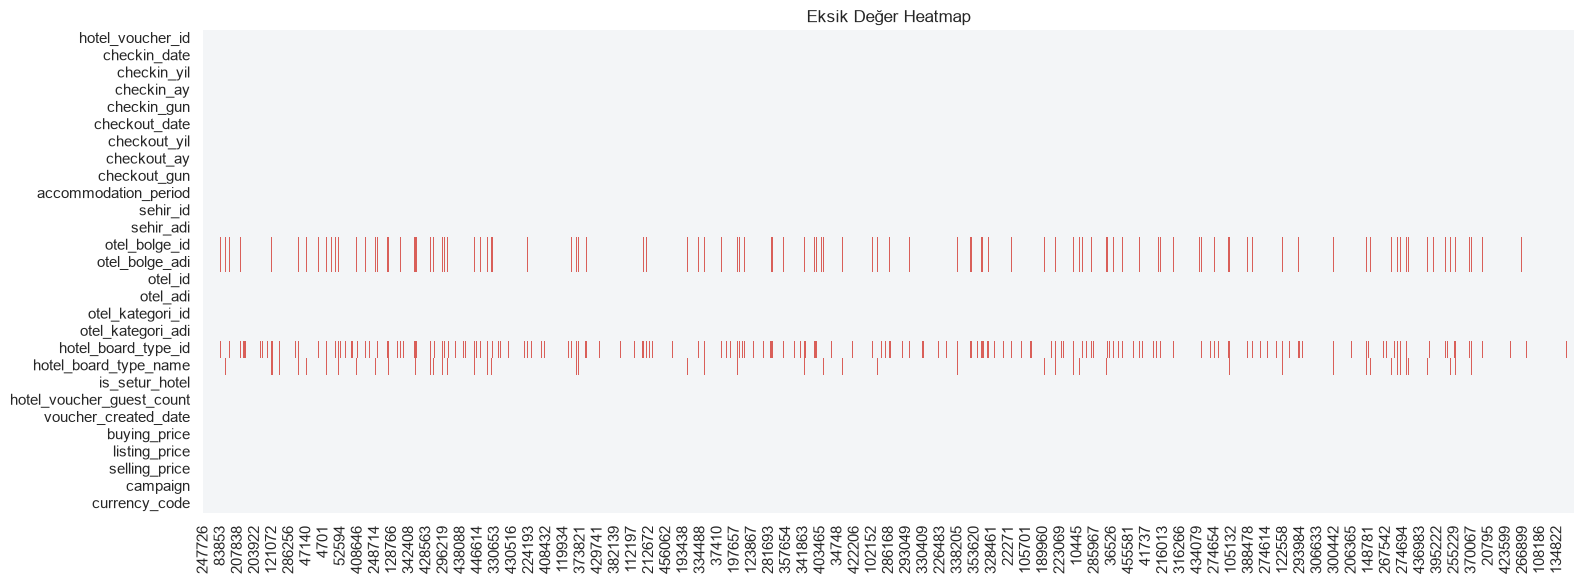

### Eksik Verilerin Otel / Bölge / Konaklama Süresi Kırılımında Yoğunlaşması

**Eksik veri oranı en yüksek 10 otel (%)**

,eksik_oran_%
otel_adi,
Λιθεία-Lithia,100.0
Şerif Paşa Konuk Evi,100.0
Şakran Otel,100.0
Holiday Inn Jeddah Corniche by IHG,100.0
Hilton Amsterdam,100.0
Heliopic Hotel & Spa,100.0
HOtel Chateau Frontenac,100.0
Grecotel Astir Palace,100.0
Four Points by Sheraton Phuket Patong Beach Resort,100.0


**Eksik veri oranı bölgelere göre (%)**

,eksik_oran_%
otel_bolge_adi,
İstanbul Gaziosmanpaşa,100.0
Çakraz,100.0
Çayırova,100.0
Çağlayan,100.0
Uzunköprü,100.0
...,...
Erdek,0.0
Akçakoca,0.0
Finike,0.0


**Eksik veri oranı konaklama süresine (inhouse) göre (%)**

,eksik_oran_%
accommodation_period,
-303,100.0
0,100.0
270,100.0
112,100.0
32,100.0
38,100.0
34,100.0
248,100.0
741,100.0


**Yorum:** Eksikler belirli otel/bölge/konaklama süresi dönemlerinde yoğunlaşıyorsa bu, veri toplama sürecindeki sistematik bir soruna (ör. yeni/entegrasyonu eksik oteller, belirli acente veya kanal, uzun/kısa konaklama dönemleri) işaret eder; dağılım rastgeleye yakınsa (MCAR) etkisi daha düşük risklidir. `otel_bolge_id`/`otel_bolge_adi` ve `hotel_board_type_id`/`hotel_board_type_name` eksikleri belirli otellerde tekrarlı görünüyorsa entegrasyon/mapping eksikliğine işaret eder ve bölge/pansiyon bazlı gruplamalarda dikkatli olunmalıdır.

In [5]:
print(f"Boyut: {df.shape[0]:,} satır x {df.shape[1]} sütun")
kolon_ozeti = pd.DataFrame({
    "kolon": df.columns,
    "tip": df.dtypes.astype(str).values,
    "benzersiz": [df[c].nunique(dropna=True) for c in df.columns],
    "eksik": df.isna().sum().values,
    "eksik_oran_%": (df.isna().mean().mul(100).round(3)).values,
})
display(kolon_ozeti)
display(df.head(10))
display(df.tail(10))
display(df.columns)

missing = kolon_ozeti.sort_values("eksik_oran_%", ascending=False)
display(Markdown("### Eksik Veri Özeti"))
display(missing)

missing_cols = missing.loc[missing["eksik"] > 0, "kolon"].tolist()

if missing_cols:
    heatmap_sample = df.isna().astype("int8").sample(min(2000, len(df)), random_state=42)
    plt.figure(figsize=(16, 6))
    sns.heatmap(heatmap_sample.T, cmap=["#f3f5f7", "#d95f59"], cbar=False)
    plt.title("Eksik Değer Heatmap")
    plt.tight_layout()
    plt.show()
    plt.close()

    display(Markdown("### Eksik Verilerin Otel / Bölge / Konaklama Süresi Kırılımında Yoğunlaşması"))
    eksik_var = df[missing_cols].isna().any(axis=1)
    miss_by_hotel = df.assign(_eksik_var=eksik_var).groupby("otel_adi")["_eksik_var"].mean().mul(100).sort_values(ascending=False)
    miss_by_region = df.assign(_eksik_var=eksik_var).groupby("otel_bolge_adi")["_eksik_var"].mean().mul(100).sort_values(ascending=False)
    miss_by_accommodation = df.assign(_eksik_var=eksik_var).groupby("accommodation_period")["_eksik_var"].mean().mul(100).sort_values(ascending=False)

    display(Markdown("**Eksik veri oranı en yüksek 10 otel (%)**"))
    display(miss_by_hotel.head(10).to_frame("eksik_oran_%"))
    display(Markdown("**Eksik veri oranı bölgelere göre (%)**"))
    display(miss_by_region.to_frame("eksik_oran_%"))
    display(Markdown("**Eksik veri oranı konaklama süresine (inhouse) göre (%)**"))
    display(miss_by_accommodation.head(15).to_frame("eksik_oran_%"))

    display(Markdown(
        "**Yorum:** Eksikler belirli otel/bölge/konaklama süresi dönemlerinde yoğunlaşıyorsa bu, veri toplama sürecindeki sistematik bir soruna "
        "(ör. yeni/entegrasyonu eksik oteller, belirli acente veya kanal, uzun/kısa konaklama dönemleri) işaret eder; dağılım rastgeleye "
        "yakınsa (MCAR) etkisi daha düşük risklidir. `otel_bolge_id`/`otel_bolge_adi` ve `hotel_board_type_id`/`hotel_board_type_name` "
        "eksikleri belirli otellerde tekrarlı görünüyorsa entegrasyon/mapping eksikliğine işaret eder ve bölge/pansiyon bazlı "
        "gruplamalarda dikkatli olunmalıdır."
    ))
else:
    display(Markdown("✓ **Veri setinde eksik değer bulunmamaktadır.**"))

## 3. Veri Kalitesi ve Rezervasyon KPI'ları

In [6]:
quality = {
    "tamamen_aynı_tekrar": int(df.duplicated().sum()),
    "tekrarlanan_voucher_id": int(df["hotel_voucher_id"].duplicated().sum()),
    "eksik_voucher_id": int(df["hotel_voucher_id"].isna().sum()),
    "negatif_fiyat": int((df[["buying_price", "listing_price", "selling_price"]] < 0).any(axis=1).sum()),
    "geçersiz_kisi": int((df["hotel_voucher_guest_count"] <= 0).sum()),
    "checkout_önce_checkin": int((df["checkout_date"] < df["checkin_date"]).sum()),
}
display(pd.Series(quality, name="kayıt_sayısı").to_frame())

display(Markdown("### İş Kurallarına Aykırı Görünen Kayıtlar (Örnekler)"))
neg_price_rows = df[(df[["buying_price", "listing_price", "selling_price"]] < 0).any(axis=1)]
invalid_guest_rows = df[df["hotel_voucher_guest_count"] <= 0]
checkout_before_checkin_rows = df[df["checkout_date"] < df["checkin_date"]]

for name, subset in [
    ("Negatif fiyat", neg_price_rows),
    ("Geçersiz kişi sayısı (<=0)", invalid_guest_rows),
    ("Checkout tarihi checkin'den önce", checkout_before_checkin_rows),
]:
    print(f"{name}: {len(subset):,} kayıt")
    display(subset.head(5))

display(Markdown(
    "**Yorum:** Negatif fiyat ve checkout/checkin tutarsızlıkları az sayıda olsa da veri girişi hatasıdır ve düzeltilmeli/filtrelenmelidir."
))

reservation = df.groupby("hotel_voucher_id", dropna=True).agg(
    kişi=("hotel_voucher_guest_count", "max")
)
display(Markdown(
    "**Not:** Rezervasyon başına kişi sayısı, `hotel_voucher_id` bazında `hotel_voucher_guest_count` alanının `max()` değeri alınarak hesaplanmıştır."
))
kpi = pd.Series({
    "toplam_rezervasyon": len(reservation),
    "toplam_yolcu": reservation["kişi"].sum(),
    "ortalama_kisi": reservation["kişi"].mean(),
    "medyan_kisi": reservation["kişi"].median(),
    "1_kisilik_oran_%": reservation["kişi"].eq(1).mean() * 100,
    "2_kisilik_oran_%": reservation["kişi"].eq(2).mean() * 100,
    "3_kisilik_oran_%": reservation["kişi"].eq(3).mean() * 100,
    "4_kisilik_oran_%": reservation["kişi"].eq(4).mean() * 100,
    "5_ve_üzeri_oran_%": reservation["kişi"].ge(5).mean() * 100,
})
display(Markdown("### Rezervasyon KPI'ları"))
display(kpi.round(2).to_frame("değer"))
reservation["kişi"].describe().to_frame("kişi_sayısı")

,kayıt_sayısı
tamamen_aynı_tekrar,0
tekrarlanan_voucher_id,0
eksik_voucher_id,0
negatif_fiyat,14
geçersiz_kisi,0
checkout_önce_checkin,1


### İş Kurallarına Aykırı Görünen Kayıtlar (Örnekler)

Negatif fiyat: 14 kayıt


,hotel_voucher_id,checkin_date,checkin_yil,checkin_ay,checkin_gun,checkout_date,checkout_yil,checkout_ay,checkout_gun,accommodation_period,sehir_id,sehir_adi,otel_bolge_id,otel_bolge_adi,otel_id,otel_adi,otel_kategori_id,otel_kategori_adi,hotel_board_type_id,hotel_board_type_name,is_setur_hotel,hotel_voucher_guest_count,voucher_created_date,buying_price,listing_price,selling_price,campaign,currency_code
2390,450603,2026-09-15,2026,9,15,2026-09-21,2026,9,21,6,29,Antalya,7930.0,Kumköy,3104,Sidemarin Kirman Premium,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,2,2026-03-02 21:47:00,-2174.2,217420.0,20654.9,1,TRY
62056,450635,2026-06-06,2026,6,6,2026-06-12,2026,6,12,6,29,Antalya,7930.0,Kumköy,3104,Sidemarin Kirman Premium,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,2,2026-03-03 07:20:00,-2141.5,214150.0,21415.0,1,TRY
63197,450605,2026-06-01,2026,6,1,2026-06-10,2026,6,10,9,29,Antalya,7930.0,Kumköy,3104,Sidemarin Kirman Premium,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,3,2026-03-02 21:57:00,-3249.0,324900.0,30865.5,1,TRY
63198,450599,2026-06-01,2026,6,1,2026-06-07,2026,6,7,6,29,Antalya,7930.0,Kumköy,3104,Sidemarin Kirman Premium,5,5 Yıldız,7.0,Ultra Her Şey Dahil,1,2,2026-03-02 21:25:00,-2166.0,216600.0,21660.0,1,TRY
280074,250260,2024-05-13,2024,5,13,2024-05-19,2024,5,19,6,29,Antalya,7756.0,Okurcalar,1091,Sui Resort Hotel,5,5 Yıldız,3.0,Her Şey Dahil,1,3,2024-03-26 10:45:00,-2310.0,92400.0,6180.0,1,TRY


Geçersiz kişi sayısı (<=0): 0 kayıt


...

**Yorum:** Negatif fiyat ve checkout/checkin tutarsızlıkları az sayıda olsa da veri girişi hatasıdır ve düzeltilmeli/filtrelenmelidir.

**Not:** Rezervasyon başına kişi sayısı, `hotel_voucher_id` bazında `hotel_voucher_guest_count` alanının `max()` değeri alınarak hesaplanmıştır.

### Rezervasyon KPI'ları

,değer
toplam_rezervasyon,473569.00
toplam_yolcu,1182158.00
ortalama_kisi,2.50
medyan_kisi,2.00
1_kisilik_oran_%,10.82
2_kisilik_oran_%,43.46
3_kisilik_oran_%,31.85
4_kisilik_oran_%,13.09
5_ve_üzeri_oran_%,0.78


,kişi_sayısı
count,473569.000000
mean,2.496274
std,0.883163
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,9.000000


## 4. Zaman, Otel ve Bölge Analizi

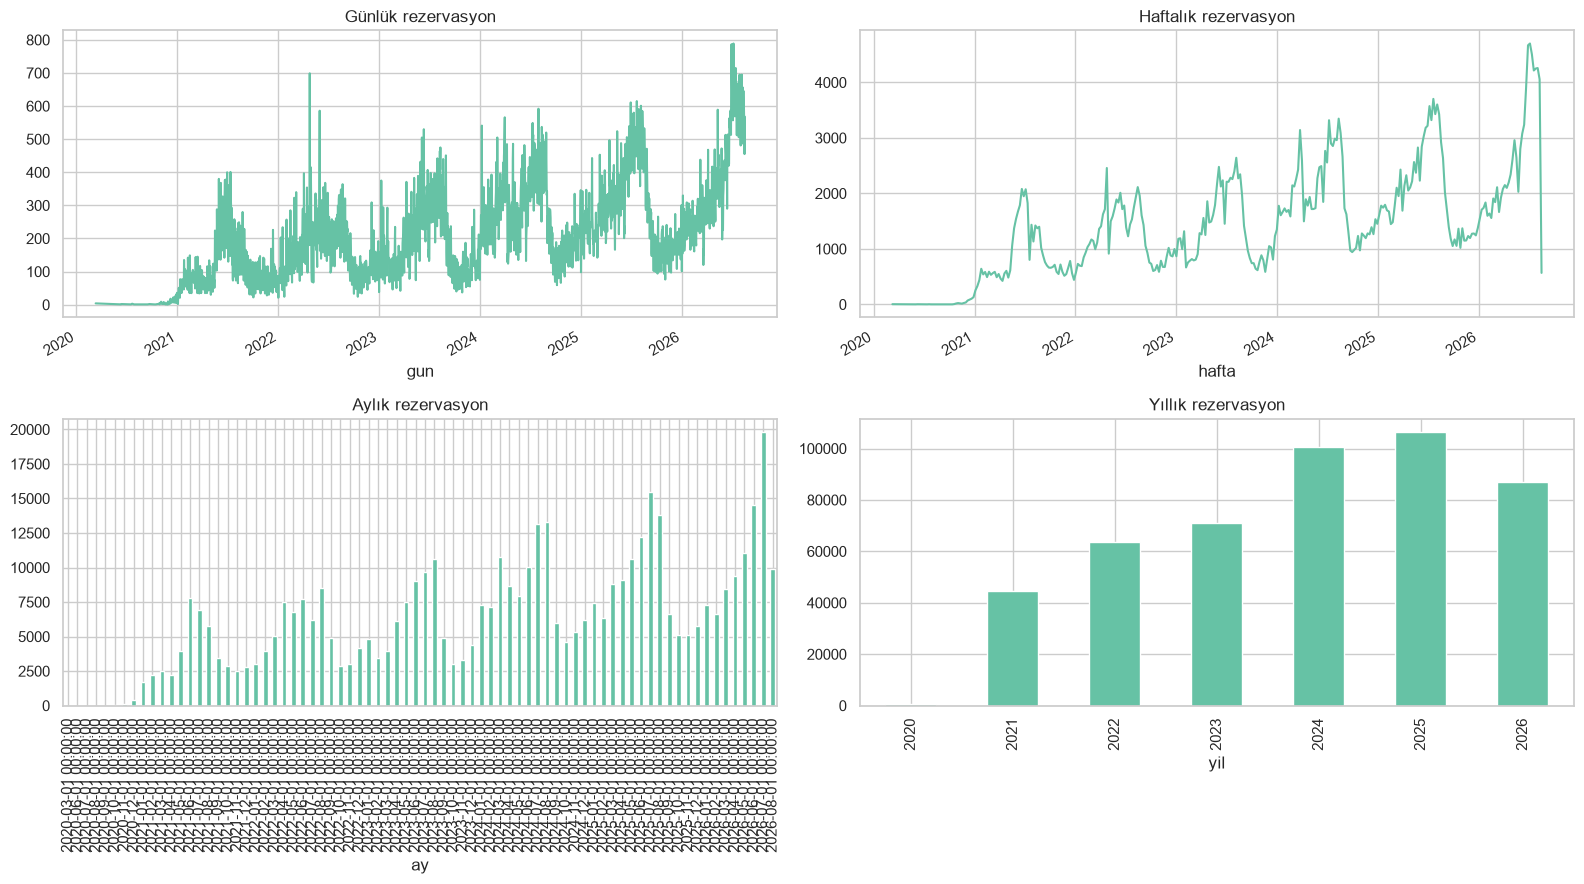

En fazla rezervasyon alan oteller


,,rezervasyon,yolcu,ortalama_kisi
otel_id,otel_adi,,,
456,Robinson Çamyuva,6430,12518,1.946812
471,Crystal Admiral Aqua Collection,5443,17280,3.174720
182358,Club Beyy Resort Hotel,5182,14410,2.780780
466,Sueno Hotels Beach Side,5041,14090,2.795080
887,Sueno Hotels Deluxe Belek,4586,13153,2.868077
786,Zeynep Hotel,4186,11885,2.839226
646,Crystal Waterworld Aqua Collection,4149,12120,2.921186
181147,Belek Beach Resort Hotel,3943,10564,2.679178
813,Champion Holiday Village,3924,10285,2.621050


,rezervasyon,yolcu,kisi_rezervasyon,pay_%
otel_bolge_adi,,,,
NaN,36564,58114,1.589378,7.720945
Girne Merkez,18732,39168,2.090967,3.955495
Sapanca,13281,34129,2.569761,2.804449
Boğazkent,12656,35878,2.834861,2.672472
Sorgun,11520,33235,2.884983,2.432592
Side,10137,29340,2.894347,2.140554
Taşlıburun,9984,28422,2.846755,2.108246
Kundu,9258,27559,2.976777,1.954942
Göynük,8955,24034,2.683864,1.890960


### Ortalama Kişi Sayısına Göre Oteller

Ortalama kişi sayısı EN YÜKSEK oteller (>= 20 rezervasyon)


...

Ortalama kişi sayısı EN DÜŞÜK oteller (>= 20 rezervasyon)


,,rezervasyon,yolcu,ortalama_kisi
otel_id,otel_adi,,,
166003,Ramada Plaza by Wyndham Bucharest Convention Center,20,20,1.0
143686,Sheraton Amman Al Nabil Hotel,21,21,1.0
165999,Holiday Inn Express Walsall M6J10 by IHG,40,40,1.0
27701,Hilton Garden Inn Qidong,46,46,1.0
178795,Amarina Abu Soma Resort & Aquapark,21,21,1.0
62369,Hilton Shenzhen Shekou Nanhai,27,27,1.0
130194,Astra Hotel Vevey,45,45,1.0
83572,Mercure Hotel Stuttgart Sindelfingen an der Messe,47,47,1.0
168553,Babylon Rotana Baghdad,48,48,1.0


**Yorum:** Az rezervasyonlu oteller ortalamayı aşırı çarpıtabildiğinden burada en az 20 rezervasyonu olan oteller filtrelendi. Yüksek ortalama kişili oteller aile/grup odaklı konumlandırmaya, düşük ortalama kişili oteller ise çift/bireysel odaklı konumlandırmaya işaret eder.

Otel bazında rezervasyon dağılımı (özet istatistik)


,rezervasyon_dagilimi
count,17794.000000
mean,26.613971
std,187.541396
min,1.000000
25%,1.000000
50%,2.000000
75%,7.000000
max,6430.000000


In [7]:
work = df.dropna(subset=["voucher_created_date"]).copy()
work["gun"] = work["voucher_created_date"].dt.floor("D")
work["hafta"] = work["voucher_created_date"].dt.to_period("W").dt.start_time
work["ay"] = work["voucher_created_date"].dt.to_period("M").dt.to_timestamp()
work["yil"] = work["voucher_created_date"].dt.year

gunluk = work.groupby("gun")["hotel_voucher_id"].nunique()
haftalik = work.groupby("hafta")["hotel_voucher_id"].nunique()
aylik = work.groupby("ay")["hotel_voucher_id"].nunique()
yillik = work.groupby("yil")["hotel_voucher_id"].nunique()

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
gunluk.plot(ax=axes[0, 0], title="Günlük rezervasyon")
haftalik.plot(ax=axes[0, 1], title="Haftalık rezervasyon")
aylik.plot(kind="bar", ax=axes[1, 0], title="Aylık rezervasyon")
yillik.plot(kind="bar", ax=axes[1, 1], title="Yıllık rezervasyon")
plt.tight_layout()
plt.show()
plt.close()

hotel_summary = df.groupby(["otel_id", "otel_adi"], dropna=False).agg(
    rezervasyon=("hotel_voucher_id", "nunique"),
    yolcu=("hotel_voucher_guest_count", "sum"),
    ortalama_kisi=("hotel_voucher_guest_count", "mean")
).sort_values("rezervasyon", ascending=False)
print("En fazla rezervasyon alan oteller")
display(hotel_summary.head(20))

region_col = "otel_bolge_adi"
region_summary = df.groupby(region_col, dropna=False).agg(
    rezervasyon=("hotel_voucher_id", "nunique"),
    yolcu=("hotel_voucher_guest_count", "sum")
)
region_summary["kisi_rezervasyon"] = region_summary["yolcu"] / region_summary["rezervasyon"]
region_summary["pay_%"] = region_summary["rezervasyon"] / region_summary["rezervasyon"].sum() * 100
display(region_summary.sort_values("rezervasyon", ascending=False).head(30))

display(Markdown("### Ortalama Kişi Sayısına Göre Oteller"))
min_res_threshold = 20  # güvenilir ortalama için minimum rezervasyon sayısı eşiği
reliable_hotels = hotel_summary[hotel_summary["rezervasyon"] >= min_res_threshold]

print(f"Ortalama kişi sayısı EN YÜKSEK oteller (>= {min_res_threshold} rezervasyon)")
display(reliable_hotels.sort_values("ortalama_kisi", ascending=False).head(15))

print(f"Ortalama kişi sayısı EN DÜŞÜK oteller (>= {min_res_threshold} rezervasyon)")
display(reliable_hotels.sort_values("ortalama_kisi", ascending=True).head(15))

display(Markdown(
    "**Yorum:** Az rezervasyonlu oteller ortalamayı aşırı çarpıtabildiğinden burada en az "
    f"{min_res_threshold} rezervasyonu olan oteller filtrelendi. Yüksek ortalama kişili oteller aile/grup odaklı "
    "konumlandırmaya, düşük ortalama kişili oteller ise çift/bireysel odaklı konumlandırmaya işaret eder."
))

print("Otel bazında rezervasyon dağılımı (özet istatistik)")
display(hotel_summary["rezervasyon"].describe().to_frame("rezervasyon_dagilimi"))

## 5. Aykırı Değerler, Frekanslar ve Korelasyon

,kolon,Q1,Q3,alt_sinir,ust_sinir,aykiri_sayi,aykiri_oran_%
11,otel_kategori_id,5.0,5.00,5.00,5.0,187317,39.554320
18,campaign,1.0,1.00,1.00,1.0,92696,19.573916
8,sehir_id,29.0,80.00,-47.50,156.5,69052,14.581191
9,otel_bolge_id,7755.0,7942.00,7474.50,8222.5,52672,11.122350
2,checkin_ay,6.0,8.00,3.00,11.0,47519,10.034229
13,is_setur_hotel,1.0,1.00,1.00,1.0,47169,9.960323
5,checkout_ay,6.0,8.00,3.00,11.0,47160,9.958422
16,listing_price,3080.0,64000.00,-88300.00,155380.0,29070,6.138493
12,hotel_board_type_id,7.0,10.00,2.50,14.5,28996,6.122867
15,buying_price,2380.0,38304.00,-51506.00,92190.0,23053,4.867928


### Sayısal Değişkenler İçin Temel İstatistikler

,count,mean,std,median,min,5%,25%,50%,75%,95%,99%,max
hotel_voucher_guest_count,473569.0,2.496274,0.883163,2.0,1.0,1.000,2.0,2.0,3.00,4.0,4.000,9.00
accommodation_period,473569.0,3.476556,2.419950,3.0,-303.0,1.000,2.0,3.0,5.00,6.0,8.000,741.00
buying_price,473569.0,26127.341395,37296.826342,13284.0,-3249.0,129.610,2380.0,13284.0,38304.00,91506.8,147829.800,8229170.61
listing_price,473569.0,44894.539337,63560.599679,20000.0,-5.0,137.604,3080.0,20000.0,64000.00,168000.0,270491.760,9381254.49
selling_price,473569.0,30122.142635,42805.831939,15298.1,-5.0,139.110,2700.0,15298.1,44311.68,105469.0,170000.132,9381254.49
campaign,473569.0,0.804261,0.396769,1.0,0.0,0.000,1.0,1.0,1.00,1.0,1.000,1.00


Frekans: sehir_adi


,sayi
sehir_adi,
Antalya,180074
Muğla,72304
İzmir,26746
Girne,18733
Aydın,16202
İstanbul,15268
Sakarya,13886
Balıkesir,10636
Bafra,8371


...

,sayi
otel_kategori_adi,
5 Yıldız,286252
4 Yıldız,77443
3 Yıldız,32888
Otel,19859
Tatil Köyü,15740
Pansiyon,12629
Butik Otel,6497
Özel Konaklama Tesisi,5727
Seçim yapılmayı bekliyor,4393


Frekans: hotel_board_type_name


,sayi
hotel_board_type_name,
Ultra Her Şey Dahil,167758
Oda Kahvaltı,82838
Her Şey Dahil,60746
Yarım Pansiyon,36655
Sadece Oda,26103
NaN,14562
Tam Pansiyon Plus,12635
Ücretsiz Kahvaltı,7165
Yarım Pansiyon Plus,5527


Frekans: currency_code


,sayi
currency_code,
TRY,385457
EUR,84844
USD,3020
GBP,208
CHF,26
CAD,6
AUD,4
DKK,3
SEK,1


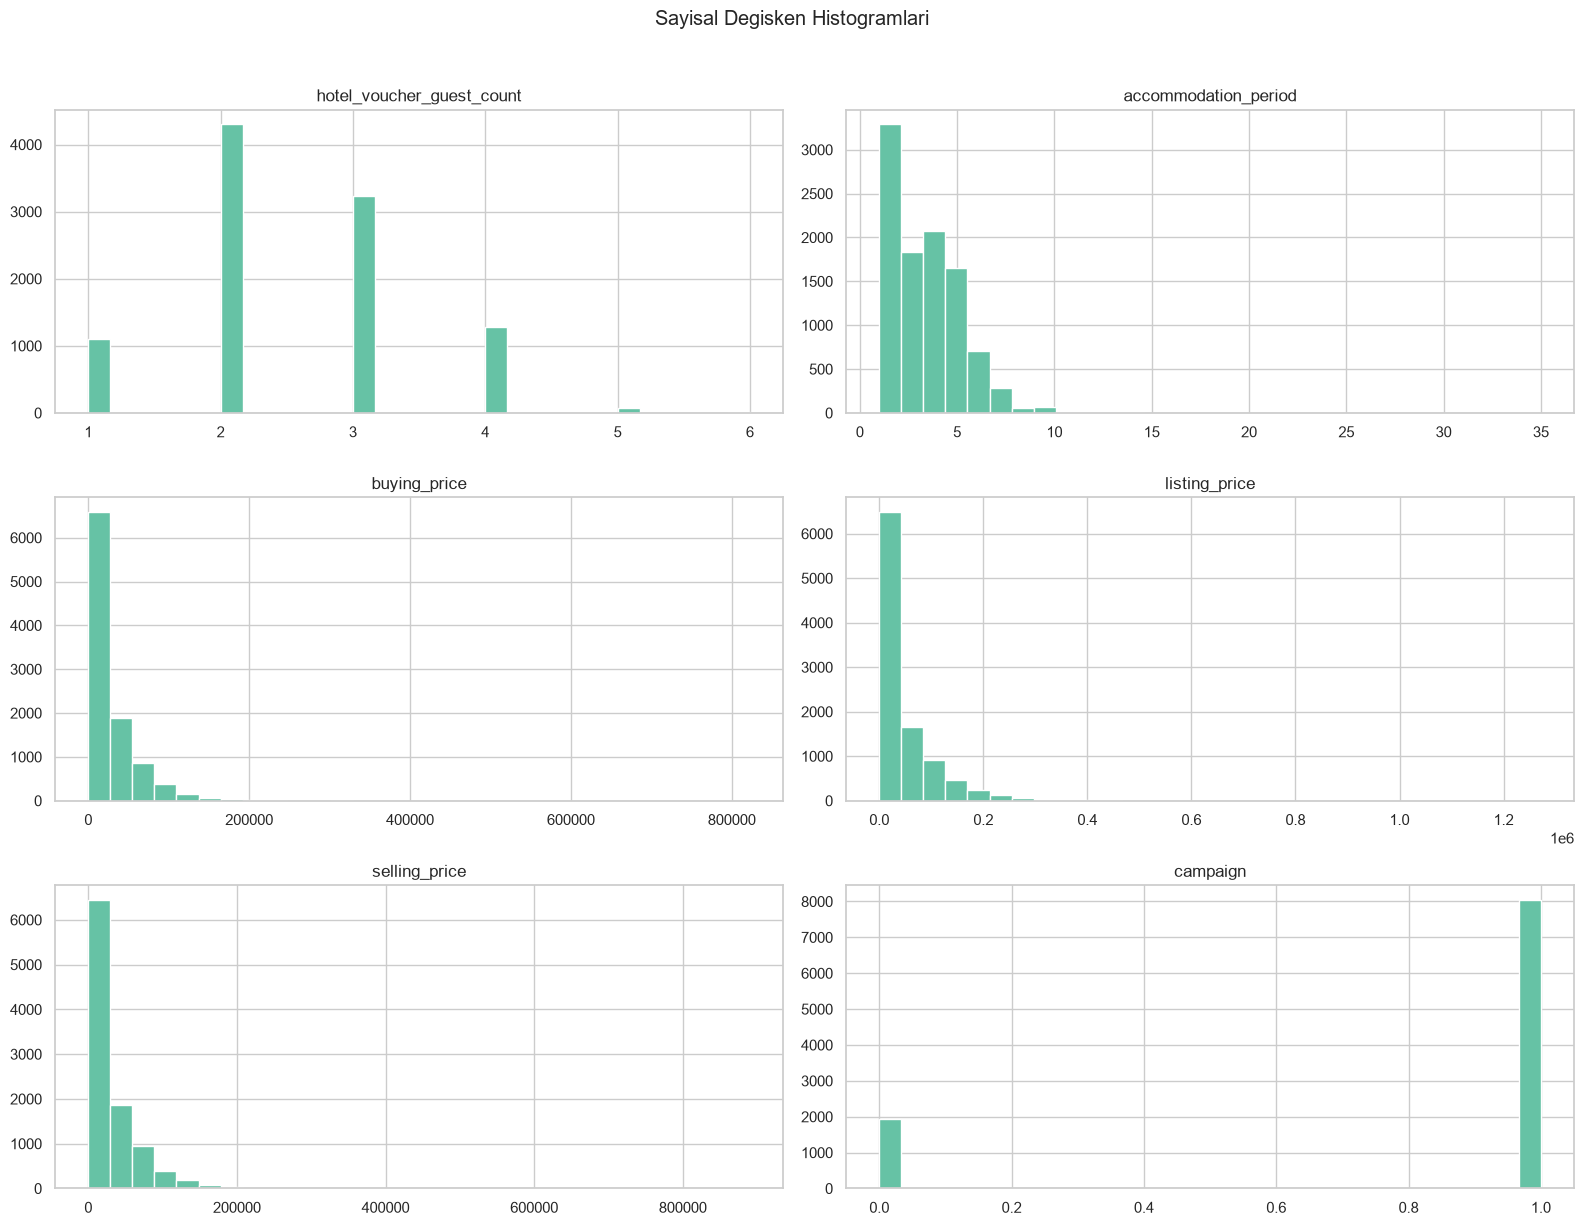

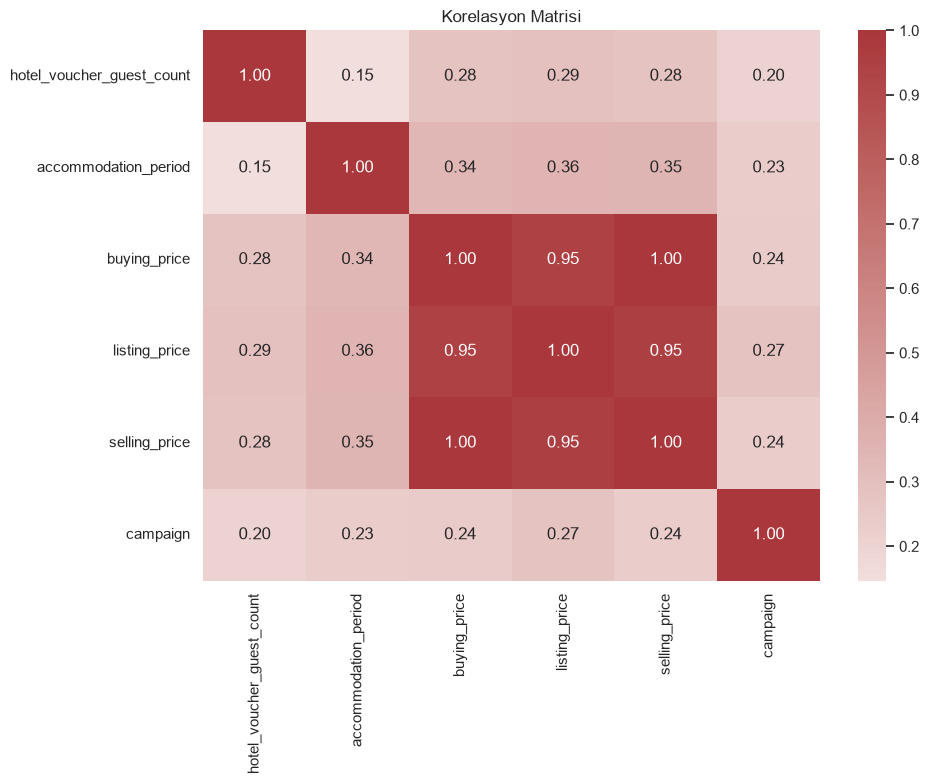

**Yorum:** IQR aykirilari veri girisi hatasi olmak zorunda degildir; buyuk aile rezervasyonu veya uzun konaklama gibi gercek ticari olaylar da olabilir. Korelasyon nedensellik gostermez, ancak hedef sizintisi ve guclu birlikte degisim icin sinyal verir.

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_rows = []
for col in numeric_cols:
    values = df[col].dropna()
    if values.nunique() > 1:
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        count = int(((df[col] < low) | (df[col] > high)).sum())
        outlier_rows.append([col, q1, q3, low, high, count, count / len(df) * 100])
outliers = pd.DataFrame(outlier_rows, columns=["kolon", "Q1", "Q3", "alt_sinir", "ust_sinir", "aykiri_sayi", "aykiri_oran_%"])
display(outliers.sort_values("aykiri_sayi", ascending=False))

display(Markdown("### Sayısal Değişkenler İçin Temel İstatistikler"))
stat_cols = [c for c in ["hotel_voucher_guest_count", "accommodation_period",
                          "buying_price", "listing_price", "selling_price", "campaign"] if c in df.columns]
desc = df[stat_cols].describe(percentiles=[.05, .25, .5, .75, .95, .99]).T
desc.insert(3, "median", df[stat_cols].median())
display(desc)

categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()
for col in categorical_cols:
    if col not in DATE_COLS:
        print(f"Frekans: {col}")
        display(df[col].value_counts(dropna=False).head(20).to_frame("sayi"))

plot_cols = [c for c in ["hotel_voucher_guest_count", "accommodation_period", "buying_price", "listing_price", "selling_price", "campaign"] if c in df.columns]
plot_sample = df[plot_cols].sample(min(10000, len(df)), random_state=42)
plot_sample.hist(figsize=(16, 12), bins=30, edgecolor="white")
plt.suptitle("Sayisal Degisken Histogramlari", y=1.02)
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(10, 8))
sns.heatmap(df[plot_cols].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()
plt.close()
display(Markdown("**Yorum:** IQR aykirilari veri girisi hatasi olmak zorunda degildir; buyuk aile rezervasyonu veya uzun konaklama gibi gercek ticari olaylar da olabilir. Korelasyon nedensellik gostermez, ancak hedef sizintisi ve guclu birlikte degisim icin sinyal verir."))

In [9]:
display(Markdown("### Fiyat Alanları İlişkisi ve İndirim Oranları"))

price_cols = ["buying_price", "listing_price", "selling_price"]
price_data = df[price_cols].replace([np.inf, -np.inf], np.nan).dropna()
price_data = price_data[(price_data["listing_price"] > 0) & (price_data["buying_price"] > 0) & (price_data["selling_price"] > 0)]

price_summary = pd.Series({
    "listing'e_göre_selling_indirimi_%": ((price_data["listing_price"] - price_data["selling_price"]) / price_data["listing_price"] * 100).median(),
    "listing'e_göre_buying_farkı_%": ((price_data["listing_price"] - price_data["buying_price"]) / price_data["listing_price"] * 100).median(),
    "buying'e_göre_selling_farkı_%": ((price_data["buying_price"] - price_data["selling_price"]) / price_data["buying_price"] * 100).median(),
    "selling_listing'den_düşük_oran_%": (price_data["selling_price"] < price_data["listing_price"]).mean() * 100,
    "selling_buying'den_düşük_oran_%": (price_data["selling_price"] < price_data["buying_price"]).mean() * 100,
})
display(price_summary.round(2).to_frame("değer"))

price_corr = price_data.corr().round(3)
display(Markdown("**Korelasyon matrisi**"))
display(price_corr)

price_data["listing_to_selling_discount_%"] = (price_data["listing_price"] - price_data["selling_price"]) / price_data["listing_price"] * 100
price_data["listing_to_buying_discount_%"] = (price_data["listing_price"] - price_data["buying_price"]) / price_data["listing_price"] * 100
price_data["selling_to_buying_difference_%"] = (price_data["buying_price"] - price_data["selling_price"]) / price_data["buying_price"] * 100
display(price_data[["listing_to_selling_discount_%", "listing_to_buying_discount_%", "selling_to_buying_difference_%"]].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(2))

display(Markdown(
    "**Not:** İndirim oranlarının medyanla birlikte raporlanması daha sağlıklıdır; ortalama, çok yüksek fiyatlı kayıtlar tarafından çarpılabilir. "
    "Modellemede fiyatları aynı para birimine çevirmeden doğrudan birlikte karşılaştırmayın; `currency_code` mutlaka dikkate alınmalıdır."
))

### Fiyat Alanları İlişkisi ve İndirim Oranları

,değer
listing'e_göre_selling_indirimi_%,20.00
listing'e_göre_buying_farkı_%,31.75
buying'e_göre_selling_farkı_%,-15.82
selling_listing'den_düşük_oran_%,79.15
selling_buying'den_düşük_oran_%,1.36


**Korelasyon matrisi**

,buying_price,listing_price,selling_price
buying_price,1.000,0.957,0.997
listing_price,0.957,1.000,0.958
selling_price,0.997,0.958,1.000


,count,mean,std,min,5%,25%,50%,75%,95%,max
listing_to_selling_discount_%,469877.0,21.58,17.68,-11.08,0.00,5.00,20.00,35.00,50.5,100.00
listing_to_buying_discount_%,469877.0,31.15,16.12,-2017.90,5.52,15.85,31.75,43.00,56.4,99.92
selling_to_buying_difference_%,469877.0,-16.04,406.89,-121699.44,-26.44,-18.75,-15.82,-11.11,0.0,100.00


**Not:** İndirim oranlarının medyanla birlikte raporlanması daha sağlıklıdır; ortalama, çok yüksek fiyatlı kayıtlar tarafından çarpılabilir. Modellemede fiyatları aynı para birimine çevirmeden doğrudan birlikte karşılaştırmayın; `currency_code` mutlaka dikkate alınmalıdır.

In [10]:
display(Markdown("## Antalya ve Muğla Odaklı Analiz"))

focus_cities = ["Antalya", "Muğla"]
focus = df[df["sehir_adi"].isin(focus_cities)].copy()
print(f"Antalya + Muğla kayıt sayısı: {len(focus):,}")

# Bölgeyi aynı otelin mevcut ve en sık görülen bölge bilgisiyle doldur.
hotel_region_mode = (
    df.dropna(subset=["otel_bolge_adi"])
      .groupby("otel_id")["otel_bolge_adi"]
      .agg(lambda values: values.mode().iat[0] if not values.mode().empty else np.nan)
)
focus["otel_bolge_adi_doldurulmus"] = focus["otel_bolge_adi"].fillna(focus["otel_id"].map(hotel_region_mode))
focus["bolge_dolduruldu"] = focus["otel_bolge_adi"].isna() & focus["otel_bolge_adi_doldurulmus"].notna()

region_fill_summary = pd.Series({
    "odak şehirlerde toplam kayıt": len(focus),
    "başlangıçta eksik bölge": int(focus["otel_bolge_adi"].isna().sum()),
    "aynı otel bilgisiyle doldurulan": int(focus["bolge_dolduruldu"].sum()),
    "doldurma sonrası hâlâ eksik": int(focus["otel_bolge_adi_doldurulmus"].isna().sum()),
})
display(Markdown("### Eksik Otel Bölgelerinin Doldurulması"))
display(region_fill_summary.to_frame("kayıt"))
display(focus.groupby(["sehir_adi", "otel_bolge_adi_doldurulmus"], dropna=False)["hotel_voucher_id"].nunique().sort_values(ascending=False).head(30).to_frame("rezervasyon"))
display(Markdown(
    "**Yöntem:** Önce aynı `otel_id` için eksik olmayan bölge değerlerinin modu kullanıldı. "
    "Aynı otelin hiçbir kaydında bölge yoksa şehir bazlı manuel otel-bölge eşlemesi veya güvenilir bir otel master tablosu gerekir; "
    "bu kayıtları rastgele doldurmamak gerekir."
))

# Para birimleri farklı olduğu için nominal sıralama ayrıca gösterilir ve para birimi belirtilir.
top_sold = (
    df.dropna(subset=["selling_price"])
      .sort_values("selling_price", ascending=False)
      [["hotel_voucher_id", "otel_adi", "sehir_adi", "otel_bolge_adi", "checkin_date", "checkout_date", "selling_price", "currency_code"]]
      .head(10)
)
display(Markdown("### Nominal Satış Fiyatı En Yüksek 10 Rezervasyon"))
display(top_sold)
display(Markdown(
    "**Uyarı:** Bu sıralama nominal tutara göredir. TRY, EUR, USD gibi para birimleri birlikte karşılaştırılmamalıdır; "
    "gerçek ticari sıralama için tutarlar tek bir para birimine çevrilmelidir."
))

# Aynı otelin yıllar içinde Setur statüsü değişmiş mi?
setur_by_hotel_year = (
    df.dropna(subset=["otel_id", "checkin_yil", "is_setur_hotel"])
      .groupby(["otel_id", "otel_adi", "checkin_yil"])["is_setur_hotel"]
      .max()
      .reset_index()
)
setur_variations = (
    setur_by_hotel_year.groupby(["otel_id", "otel_adi"])["is_setur_hotel"]
    .agg(yil_sayisi="size", farkli_deger_sayisi="nunique", degerler=lambda values: sorted(values.unique().tolist()))
)
setur_variations = setur_variations[setur_variations["farkli_deger_sayisi"] > 1]

focus_setur_variations = setur_variations.loc[
    setur_variations.index.get_level_values("otel_id").isin(focus["otel_id"].unique())
]
display(Markdown("### `is_setur_hotel` Değerinin Yıllar Arasında Değişimi"))
print(f"Genel olarak statüsü yıllar arasında değişen otel sayısı: {len(setur_variations):,}")
print(f"Antalya/Muğla'da statüsü değişen otel sayısı: {len(focus_setur_variations):,}")
display(focus_setur_variations.sort_values("yil_sayisi", ascending=False).head(30))
display(Markdown(
    "**Yorum:** Aynı otelin bazı yıllarda 0, bazı yıllarda 1 olması mümkündür; bu nedenle `is_setur_hotel` sabit otel özelliği gibi değil, "
    "yıl veya rezervasyon tarihi ile birlikte değerlendirilmelidir."
))

## Antalya ve Muğla Odaklı Analiz

Antalya + Muğla kayıt sayısı: 252,378


### Eksik Otel Bölgelerinin Doldurulması

,kayıt
odak şehirlerde toplam kayıt,252378
başlangıçta eksik bölge,214
aynı otel bilgisiyle doldurulan,0
doldurma sonrası hâlâ eksik,214


rezervasyon
sehir_adi otel_bolge_adi_doldurulmus             
Antalya   Boğazkent                         12656
          Sorgun                            11511
          Side                              10137
          Taşlıburun                         9984
          Kundu                              9258
          Göynük                             8955
          İskele Mevki                       8338
          Kumköy                             8294
          Çamyuva                            7912
          Avsallar                           7879
          Beldibi                            7722
          Kızılot                            7526
Muğla     Torba                              7509
Antalya   Okurcalar                          7265
          Kızılağaç                          5599
          Üç Kum Tepesi                      5503
Muğla     Marmaris                           5106
          Sarıgerme                          4884
Antalya   Tekirova                           4879
Muğla     Güvercinlik                        4812
          Marmaris İçmeler                   4298
Antalya   Kiriş                              4294
Muğla     Yalıkavak                          3603
Antalya   Kemer                              3545
          Çolaklı                            3530
          İncekum                            3490
          Belek                              3487
          Acısu                              3279
Muğla     Yalıçiftlik                        3210
          Bardakçı                           3176

...

**Uyarı:** Bu sıralama nominal tutara göredir. TRY, EUR, USD gibi para birimleri birlikte karşılaştırılmamalıdır; gerçek ticari sıralama için tutarlar tek bir para birimine çevrilmelidir.

### `is_setur_hotel` Değerinin Yıllar Arasında Değişimi

Genel olarak statüsü yıllar arasında değişen otel sayısı: 0
Antalya/Muğla'da statüsü değişen otel sayısı: 0


,,yil_sayisi,farkli_deger_sayisi,degerler
otel_id,otel_adi,,,


**Yorum:** Aynı otelin bazı yıllarda 0, bazı yıllarda 1 olması mümkündür; bu nedenle `is_setur_hotel` sabit otel özelliği gibi değil, yıl veya rezervasyon tarihi ile birlikte değerlendirilmelidir.

## 6. Rezervasyon Dağılımı ve Grafik Yorumları

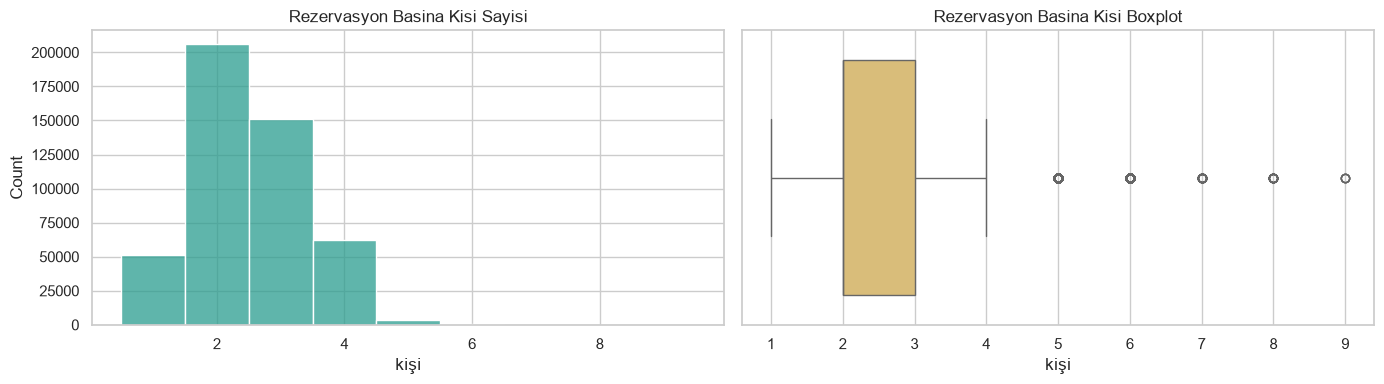

**Yorum:** Histogram rezervasyonlarin bireysel, cift veya aile agirlikli oldugunu gosterir. Boxplot, yuksek kisi sayili rezervasyonlarin ortalamayi ne kadar etkiledigini gosterir.

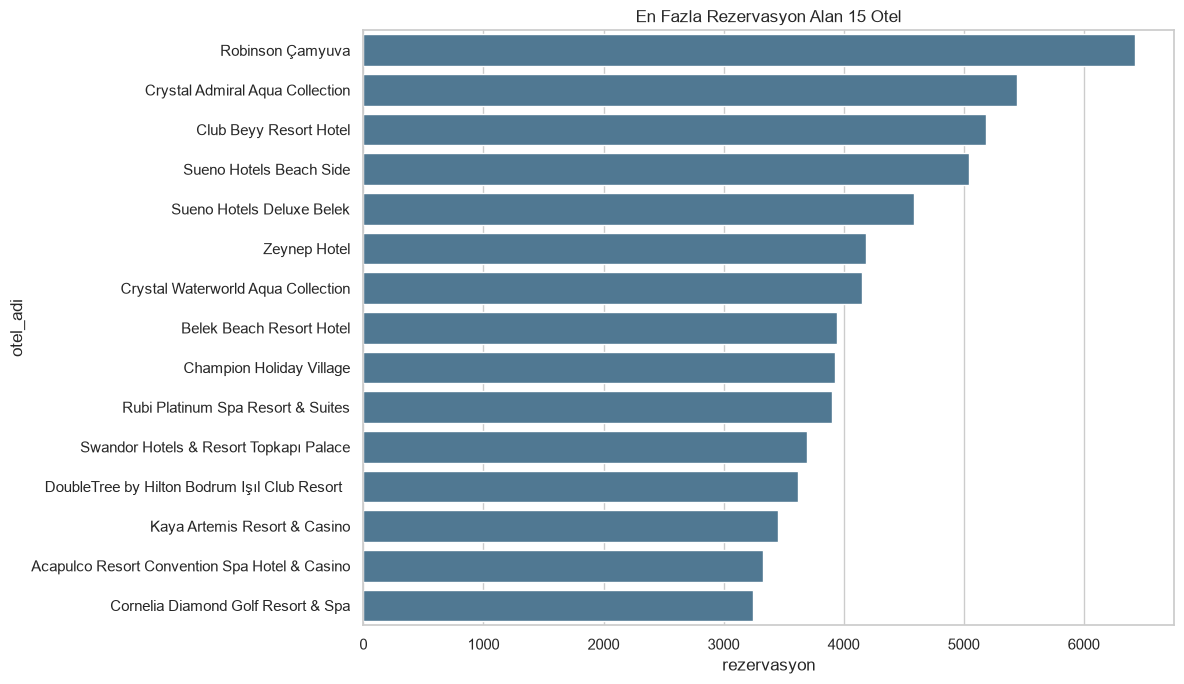

**Yorum:** Bu grafik talebin hangi otellerde yogunlastigini ve kapasite planlamasinda hangi tesislerin oncelikli oldugunu gosterir.

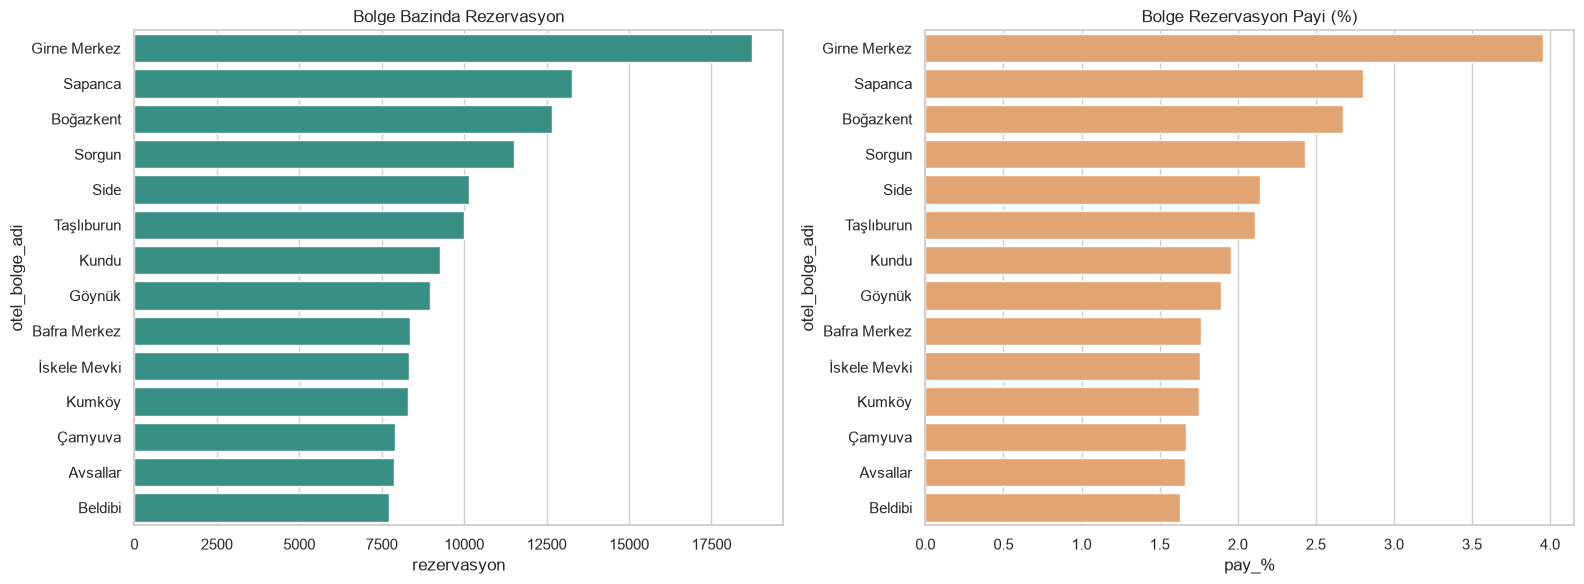

**Yorum:** Bolge payi satis ve kapasite onceligini; kisi/rezervasyon orani ise bolgesel musteri profilini gosterir.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(reservation["kişi"].dropna(), discrete=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Rezervasyon Basina Kisi Sayisi")
sns.boxplot(x=reservation["kişi"].dropna(), ax=axes[1], color="#e9c46a")
axes[1].set_title("Rezervasyon Basina Kisi Boxplot")
plt.tight_layout()
plt.show()
plt.close()

display(Markdown("**Yorum:** Histogram rezervasyonlarin bireysel, cift veya aile agirlikli oldugunu gosterir. Boxplot, yuksek kisi sayili rezervasyonlarin ortalamayi ne kadar etkiledigini gosterir."))

top_hotels = hotel_summary.head(15).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=top_hotels, y="otel_adi", x="rezervasyon", color="#457b9d")
plt.title("En Fazla Rezervasyon Alan 15 Otel")
plt.tight_layout()
plt.show()
plt.close()
display(Markdown("**Yorum:** Bu grafik talebin hangi otellerde yogunlastigini ve kapasite planlamasinda hangi tesislerin oncelikli oldugunu gosterir."))

top_regions = region_summary.sort_values("rezervasyon", ascending=False).head(15).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_regions, y=region_col, x="rezervasyon", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Bolge Bazinda Rezervasyon")
sns.barplot(data=top_regions, y=region_col, x="pay_%", ax=axes[1], color="#f4a261")
axes[1].set_title("Bolge Rezervasyon Payi (%)")
plt.tight_layout()
plt.show()
plt.close()
display(Markdown("**Yorum:** Bolge payi satis ve kapasite onceligini; kisi/rezervasyon orani ise bolgesel musteri profilini gosterir."))

## 7. Sezon Isı Haritası, İş Analizi ve Yönetici Özeti

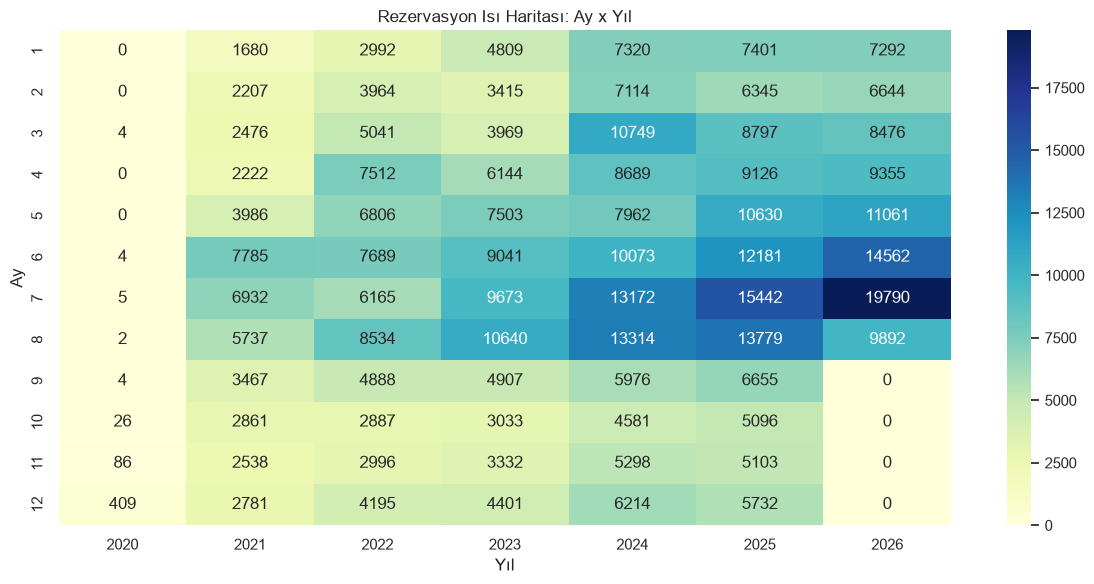

**Yorum:** Koyu hücreler rezervasyon talebinin yoğunlaştığı ay-yıl dönemlerini gösterir. Bu sinyal sezonluk tahmin ve kampanya planlamasında kullanılabilir.

,rezervasyon
sezon,
Yaz,194412
İlkbahar,130508
Kış,84915
Sonbahar,63734


## İş Analizi ve İçgörüler


- **Rezervasyonlar ağırlıklı olarak kaç kişilik?** 1 kişilik oran %10.8, 2 kişilik oran %43.5; bu ikisi rezervasyonların çoğunluğunu oluşturuyor.
- **Aile mi bireysel mi baskın?** 3+ kişilik (aile/grup) rezervasyon oranı %45.7; bu oran ikili+bireysel toplam orandan (%54.3) düşük olduğundan çift/bireysel rezervasyonlar baskındır.
- **Hangi oteller daha yüksek kişi sayılı rezervasyon çekiyor?** Örneğin **Villa Kent Termal Otel Afyon** ve "Ortalama Kişi Sayısına Göre Oteller" tablosundaki oteller; genelde tatil köyü/her şey dahil kategorisindeki tesisler öne çıkıyor.
- **Hangi dönemlerde talep yoğunlaşıyor?** En yoğun ay **2026-07**, en yoğun sezon **Yaz**; yukarıdaki ay x yıl ısı haritası bu yoğunlaşmayı teyit ediyor.
- **Dikkat edilmesi gereken kalite problemleri var mı?** Evet: negatif fiyat, checkout/checkin tutarsızlığı ve `accommodation_period`'ın tarih farkıyla uyuşmaması yukarıda listelendi; ayrıca `otel_bolge_*` ve `hotel_board_type_*` alanlarında %3-8 aralığında eksik veri var.
- **Modelleme öncesi hangi temizlik işlemleri gerekli?** Geçersiz/negatif değerli kayıtların filtrelenmesi, voucher bazında tekilleştirme, eksik bölge/pansiyon bilgisinin imputasyonu veya ayrı kategori olarak işaretlenmesi, LOS için tarih farkının kullanılması.


## 8. Yönetici Özeti

### Veri kalitesi özeti
- Veri boyutu: **473,569 satır x 40 sütun**.
- Tamamen aynı tekrar: **0**.
- Benzersiz rezervasyon: **473,569**.
- Kritik kalite kontrolleri yukarıdaki tabloda raporlandı.

### En önemli 10 bulgu
1. Toplam rezervasyon: **473,569**.
2. Toplam yolcu: **1,182,158**.
3. Ortalama kişi: **2.50**; medyan: **2.00**.
4. 1 kişilik oran: **10.82%**.
5. 2 kişilik oran: **43.46%**.
6. 5+ kişilik oran: **0.78%**.
7. En çok rezervasyon alan oteller `hotel_summary` tablosunda listelendi.
8. Bölge payları ve kişi/rezervasyon oranları `region_summary` tablosunda listelendi.
9. Aylık-yıllık yoğunluk ısı haritasında gösterildi.
10. Aykırı değerler iş hatası değil, gerçek yüksek hacimli rezervasyon da olabilir.

### Modelleme öncesi öneriler
- `hotel_voucher_id` ile otel-tarih seviyesinde hedef rezervasyon sayısı üret.
- `voucher_created_date` temel zaman ekseni olsun; rastgele train-test bölme kullanma.
- Lead time, gün/hafta/ay, hafta sonu, sezon, resmi tatil, fiyat ve kampanya özelliklerini üret.
- Otel ve bölge bazında lag-7/14/28 ve hareketli ortalamalar ekle.
- Seasonal Naive ile CatBoost/LightGBM global modeli karşılaştır.

### Potansiyel riskler
- Aynı voucher birden fazla satırdaysa satır sayısı rezervasyon sayısı değildir.
- Tahmin anında bilinmeyen fiyat veya kampanya alanları hedef sızıntısı yaratabilir.
- Sıfır hedefler nedeniyle MAPE yerine MAE, WAPE ve sMAPE kullan.


In [10]:
work["ay_num"] = work["voucher_created_date"].dt.month
month_year = work.pivot_table(index="ay_num", columns="yil", values="hotel_voucher_id", aggfunc=pd.Series.nunique, fill_value=0)
plt.figure(figsize=(12, 6))
sns.heatmap(month_year, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Rezervasyon Isı Haritası: Ay x Yıl")
plt.xlabel("Yıl")
plt.ylabel("Ay")
plt.tight_layout()
plt.show()
plt.close()
display(Markdown("**Yorum:** Koyu hücreler rezervasyon talebinin yoğunlaştığı ay-yıl dönemlerini gösterir. Bu sinyal sezonluk tahmin ve kampanya planlamasında kullanılabilir."))

work["sezon"] = work["voucher_created_date"].dt.month.map({12:"Kış", 1:"Kış", 2:"Kış", 3:"İlkbahar", 4:"İlkbahar", 5:"İlkbahar", 6:"Yaz", 7:"Yaz", 8:"Yaz", 9:"Sonbahar", 10:"Sonbahar", 11:"Sonbahar"})
season_summary = work.groupby("sezon")["hotel_voucher_id"].nunique().sort_values(ascending=False).to_frame("rezervasyon")
display(season_summary)

display(Markdown("## İş Analizi ve İçgörüler"))
tek_kisi_oran = kpi["1_kisilik_oran_%"]
iki_kisi_oran = kpi["2_kisilik_oran_%"]
aile_oran = kpi["3_kisilik_oran_%"] + kpi["4_kisilik_oran_%"] + kpi["5_ve_üzeri_oran_%"]

en_yogun_ay = aylik.idxmax().strftime("%Y-%m") if len(aylik) else "N/A"
en_yogun_sezon = season_summary["rezervasyon"].idxmax()
en_yuksek_kisi_otel = reliable_hotels.sort_values("ortalama_kisi", ascending=False).index.get_level_values("otel_adi")[0]

insights = f"""
- **Rezervasyonlar ağırlıklı olarak kaç kişilik?** 1 kişilik oran %{tek_kisi_oran:.1f}, 2 kişilik oran %{iki_kisi_oran:.1f}; bu ikisi rezervasyonların çoğunluğunu oluşturuyor.
- **Aile mi bireysel mi baskın?** 3+ kişilik (aile/grup) rezervasyon oranı %{aile_oran:.1f}; bu oran ikili+bireysel toplam orandan (%{tek_kisi_oran + iki_kisi_oran:.1f}) düşük olduğundan çift/bireysel rezervasyonlar baskındır.
- **Hangi oteller daha yüksek kişi sayılı rezervasyon çekiyor?** Örneğin **{en_yuksek_kisi_otel}** ve "Ortalama Kişi Sayısına Göre Oteller" tablosundaki oteller; genelde tatil köyü/her şey dahil kategorisindeki tesisler öne çıkıyor.
- **Hangi dönemlerde talep yoğunlaşıyor?** En yoğun ay **{en_yogun_ay}**, en yoğun sezon **{en_yogun_sezon}**; yukarıdaki ay x yıl ısı haritası bu yoğunlaşmayı teyit ediyor.
- **Dikkat edilmesi gereken kalite problemleri var mı?** Evet: negatif fiyat, checkout/checkin tutarsızlığı ve `accommodation_period`'ın tarih farkıyla uyuşmaması yukarıda listelendi; ayrıca `otel_bolge_*` ve `hotel_board_type_*` alanlarında %3-8 aralığında eksik veri var.
- **Modelleme öncesi hangi temizlik işlemleri gerekli?** Geçersiz/negatif değerli kayıtların filtrelenmesi, voucher bazında tekilleştirme, eksik bölge/pansiyon bilgisinin imputasyonu veya ayrı kategori olarak işaretlenmesi, LOS için tarih farkının kullanılması.
"""
display(Markdown(insights))

summary = f"""## 8. Yönetici Özeti

### Veri kalitesi özeti
- Veri boyutu: **{len(df):,} satır x {len(df.columns)} sütun**.
- Tamamen aynı tekrar: **{quality['tamamen_aynı_tekrar']:,}**.
- Benzersiz rezervasyon: **{len(reservation):,}**.
- Kritik kalite kontrolleri yukarıdaki tabloda raporlandı.

### En önemli 10 bulgu
1. Toplam rezervasyon: **{kpi['toplam_rezervasyon']:,.0f}**.
2. Toplam yolcu: **{kpi['toplam_yolcu']:,.0f}**.
3. Ortalama kişi: **{kpi['ortalama_kisi']:.2f}**; medyan: **{kpi['medyan_kisi']:.2f}**.
4. 1 kişilik oran: **{kpi['1_kisilik_oran_%']:.2f}%**.
5. 2 kişilik oran: **{kpi['2_kisilik_oran_%']:.2f}%**.
6. 5+ kişilik oran: **{kpi['5_ve_üzeri_oran_%']:.2f}%**.
7. En çok rezervasyon alan oteller `hotel_summary` tablosunda listelendi.
8. Bölge payları ve kişi/rezervasyon oranları `region_summary` tablosunda listelendi.
9. Aylık-yıllık yoğunluk ısı haritasında gösterildi.
10. Aykırı değerler iş hatası değil, gerçek yüksek hacimli rezervasyon da olabilir.

### Modelleme öncesi öneriler
- `hotel_voucher_id` ile otel-tarih seviyesinde hedef rezervasyon sayısı üret.
- `voucher_created_date` temel zaman ekseni olsun; rastgele train-test bölme kullanma.
- Lead time, gün/hafta/ay, hafta sonu, sezon, resmi tatil, fiyat ve kampanya özelliklerini üret.
- Otel ve bölge bazında lag-7/14/28 ve hareketli ortalamalar ekle.
- Seasonal Naive ile CatBoost/LightGBM global modeli karşılaştır.

### Potansiyel riskler
- Aynı voucher birden fazla satırdaysa satır sayısı rezervasyon sayısı değildir.
- Tahmin anında bilinmeyen fiyat veya kampanya alanları hedef sızıntısı yaratabilir.
- Sıfır hedefler nedeniyle MAPE yerine MAE, WAPE ve sMAPE kullan.
"""
display(Markdown(summary))

In [ ]:
display(Markdown("## Son DataFrame Hali"))
print(f"Son DataFrame boyutu: {df.shape[0]:,} satır x {df.shape[1]} sütun")
display(df.head())